# Tema 9
## Librerías

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from google.colab import files

ModuleNotFoundError: No module named 'google'

## Introducción

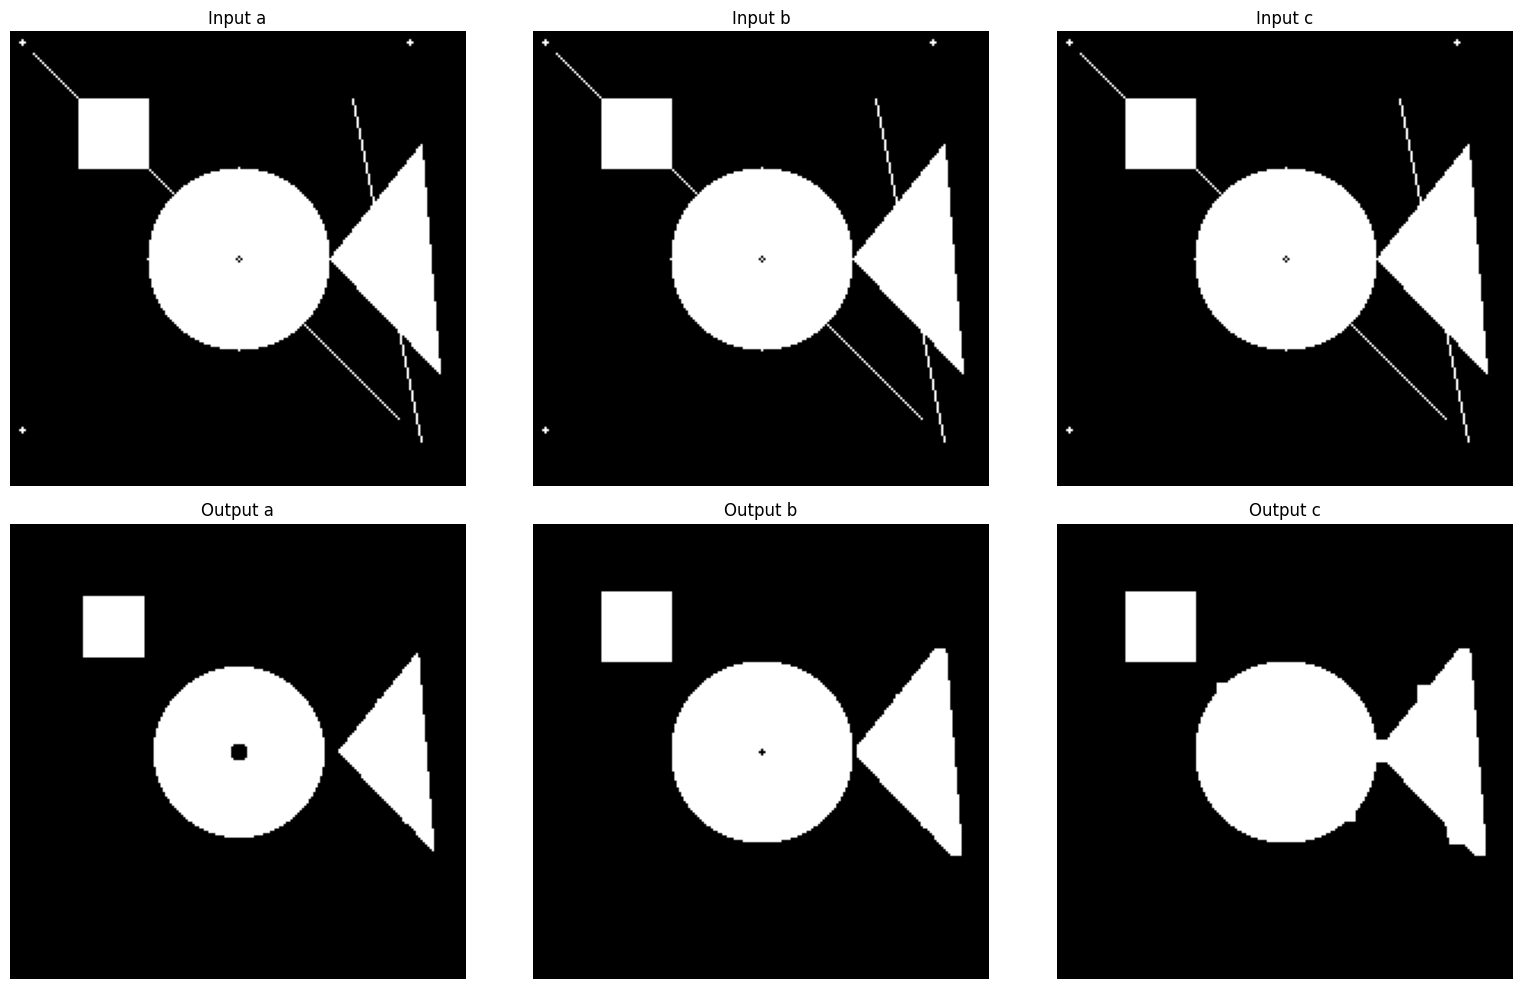

In [2]:
# Crear una función para mostrar imágenes
def plot_images(input_images, output_images, titles):
    fig, axes = plt.subplots(2, len(input_images), figsize=(16, 10))
    for i, img in enumerate(input_images):
        axes[0, i].imshow(img, cmap='gray')
        axes[0, i].set_title(f"Input {titles[i]}")
        axes[0, i].axis('off')
    for i, img in enumerate(output_images):
        axes[1, i].imshow(img, cmap='gray')
        axes[1, i].set_title(f"Output {titles[i]}")
        axes[1, i].axis('off')
    plt.tight_layout()
    plt.show()

# Imagen ejemplo a)
img_a = np.zeros((200, 200), dtype=np.uint8)
cv2.circle(img_a, (100, 100), 40, 255, -1)
cv2.circle(img_a, (5, 5), 1, 255, -1)
cv2.circle(img_a, (175, 5), 1, 255, -1)
cv2.circle(img_a, (5, 175), 1, 255, -1)
cv2.circle(img_a, (100, 100), 1, 0, -1)
cv2.rectangle(img_a, (30, 30), (60, 60), 255, -1)
cv2.line(img_a, (150, 30), (180, 180), 255, 1)
cv2.line(img_a, (10, 10), (170, 170), 255, 1)
triangle_points = np.array([[140, 100], [180, 50], [188, 150]], np.int32)
cv2.polylines(img_a, [triangle_points], isClosed=True, color=(0, 255, 0), thickness=1)
cv2.fillPoly(img_a, [triangle_points], color=(255, 0, 0))

# Imagen ejemplo b)
img_b = np.zeros((200, 200), dtype=np.uint8)
cv2.ellipse(img_b, (100, 100), (60, 40), 0, 0, 360, 255, -1)
cv2.ellipse(img_b, (100, 100), (10, 5), 0, 0, 360, 0, -1)

# Imagen ejemplo c)
img_c = np.zeros((200, 200), dtype=np.uint8)
cv2.rectangle(img_c, (50, 50), (150, 150), 255, -1)
cv2.circle(img_c, (100, 100), 30, 0, -1)
cv2.rectangle(img_c, (70, 70), (130, 130), 0, -1)

# Operaciones morfológicas
kernel = np.ones((5, 5), np.uint8)

# Erosión
output_a = cv2.erode(img_a, kernel, iterations=1)

# Apertura (Erosión seguida de dilatación)
output_b = cv2.morphologyEx(img_a, cv2.MORPH_OPEN, kernel)

# Clausura (Dilatación seguida de erosión)
output_c = cv2.morphologyEx(img_a, cv2.MORPH_CLOSE, kernel)
output_c = cv2.morphologyEx(output_c, cv2.MORPH_OPEN, kernel)


# Mostrar resultados
input_images = [img_a, img_a, img_a]
output_images = [output_a, output_b, output_c]
titles = ["a", "b", "c"]

plot_images(input_images, output_images, titles)

Saving hoja.png to hoja (4).png


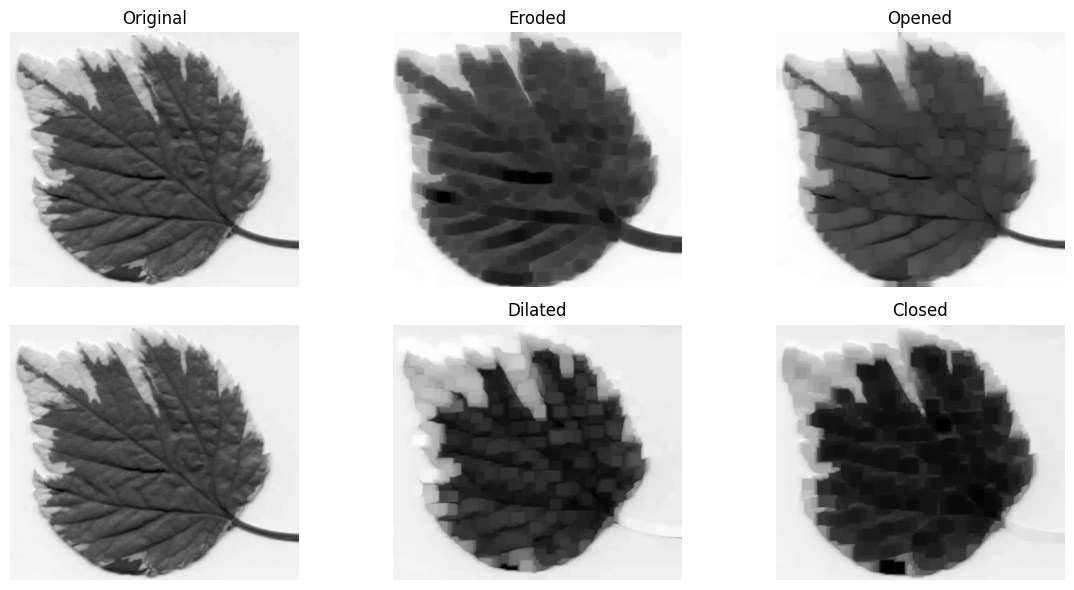

In [14]:
# Subir la imagen desde tu computadora
uploaded = files.upload()

# Cargar la imagen (usando el primer archivo cargado)
image_path = list(uploaded.keys())[0]
original_image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Realizar transformaciones morfológicas
kernel = np.ones((5, 5), np.uint8)
eroded = cv2.erode(original_image, kernel, iterations=3)
dilated = cv2.dilate(original_image, kernel, iterations=3)
opened = cv2.morphologyEx(original_image, cv2.MORPH_OPEN, np.ones((15, 15), np.uint8))
opened = cv2.morphologyEx(opened, cv2.MORPH_OPEN, np.ones((15, 15), np.uint8))
closed = cv2.morphologyEx(original_image, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))
closed = cv2.morphologyEx(closed, cv2.MORPH_CLOSE, np.ones((15, 15), np.uint8))


# Crear el diseño del gráfico
fig, axs = plt.subplots(2, 3, figsize=(12, 6))
axs = axs.flatten()

# Limpiar todos los subplots
for ax in axs:
    ax.axis('off')

# Mostrar la imagen original ocupando desde (0, 1) a (1, 2)
axs[0].imshow(original_image, cmap='gray')
axs[0].set_title("Original")
axs[0].axis('off')
axs[3].imshow(original_image, cmap='gray')
axs[3].axis('off')

# Mostrar la imagen erosionada
axs[1].imshow(eroded, cmap='gray')
axs[1].set_title("Eroded")
axs[1].axis('off')

# Mostrar la imagen abierta
axs[2].imshow(opened, cmap='gray')
axs[2].set_title("Opened")
axs[2].axis('off')

# Mostrar la imagen dilatada
axs[4].imshow(dilated, cmap='gray')
axs[4].set_title("Dilated")
axs[4].axis('off')

# Mostrar la imagen cerrada
axs[5].imshow(closed, cmap='gray')
axs[5].set_title("Closed")
axs[5].axis('off')

plt.tight_layout()
plt.show()

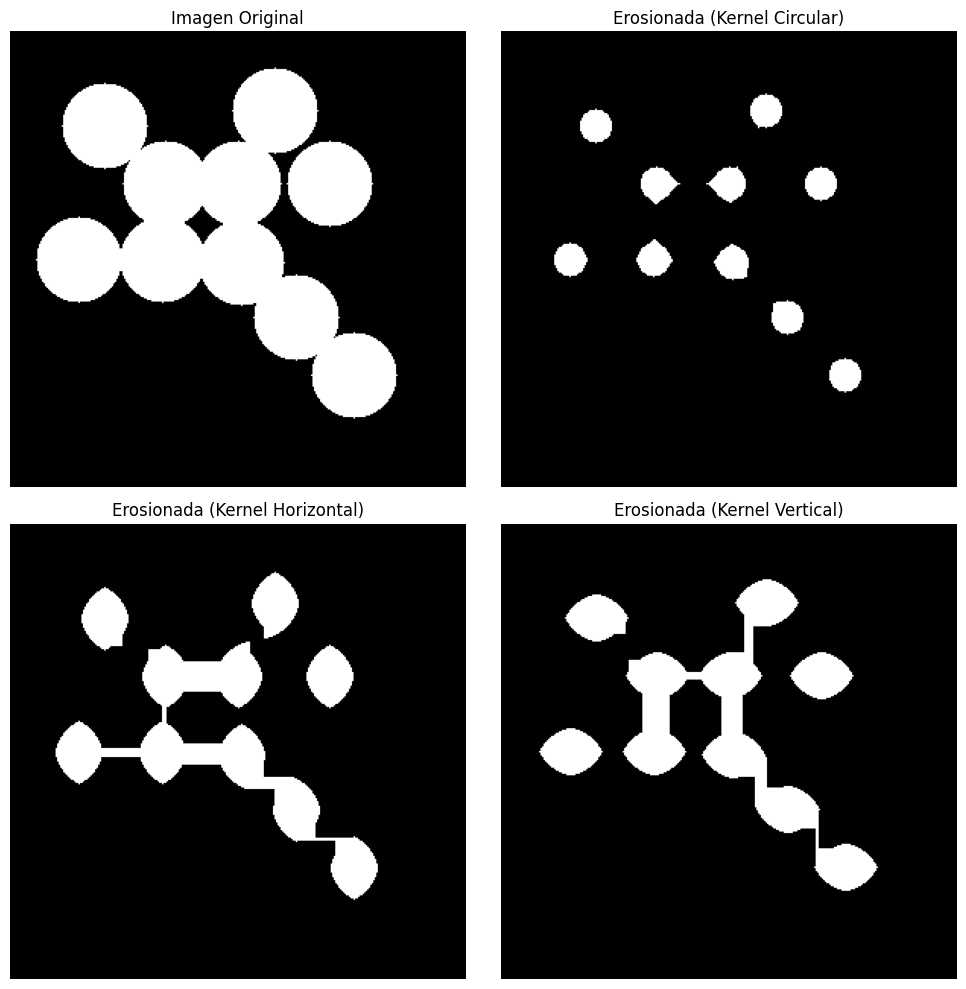

In [83]:
# Crear un lienzo negro
image = np.zeros((300, 300), dtype=np.uint8)  # Crear un lienzo negro de 300x300 píxeles

# Dibujar círculos blancos en el patrón deseado
centers = [(62, 62), (102, 100), (152, 152), (188, 188), (226, 226),
           (45, 150), (100, 150), (174, 52), (150, 100), (210, 100)]
radius = 28

for center in centers:
    cv2.circle(image, center, radius, (255), -1)  # Dibujar círculos blancos llenos

# Crear un kernel circular para la erosión
kernel_size = 35
kernel_circular = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (kernel_size, kernel_size))
eroded_circular = cv2.erode(image, kernel_circular, iterations=1)

# Crear un kernel rectangular en la dirección X (horizontal)
kernel_horizontal = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 10))
eroded_horizontal = cv2.erode(image, kernel_horizontal, iterations=1)

# Crear un kernel rectangular en la dirección Y (vertical)
kernel_vertical = cv2.getStructuringElement(cv2.MORPH_RECT, (10, 25))
eroded_vertical = cv2.erode(image, kernel_vertical, iterations=1)

# Mostrar todas las imágenes
plt.figure(figsize=(10, 10))

# Imagen original
plt.subplot(2, 2, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Imagen erosionada con kernel circular
plt.subplot(2, 2, 2)
plt.title("Erosionada (Kernel Circular)")
plt.imshow(eroded_circular, cmap='gray')
plt.axis('off')

# Imagen erosionada con kernel horizontal
plt.subplot(2, 2, 3)
plt.title("Erosionada (Kernel Horizontal)")
plt.imshow(eroded_horizontal, cmap='gray')
plt.axis('off')

# Imagen erosionada con kernel vertical
plt.subplot(2, 2, 4)
plt.title("Erosionada (Kernel Vertical)")
plt.imshow(eroded_vertical, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

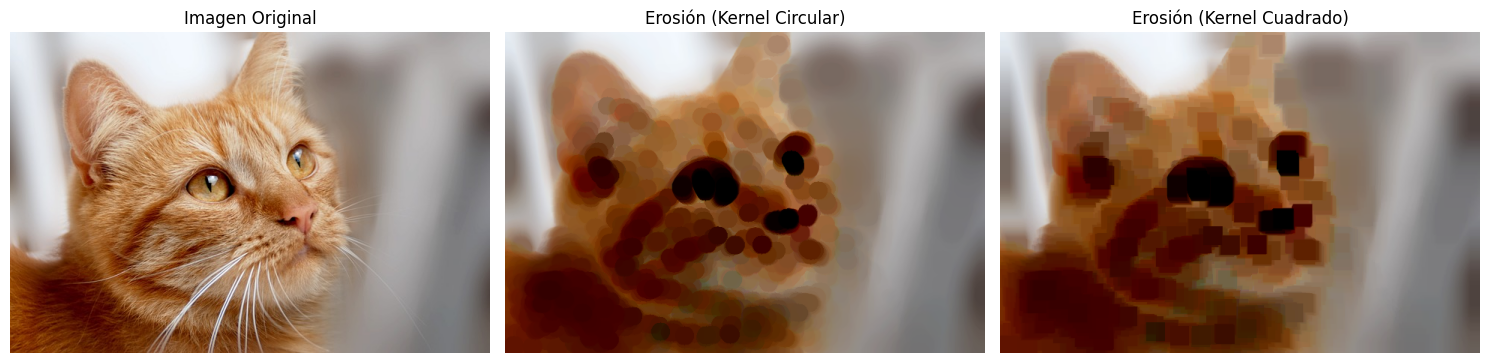

In [92]:
# # Cargar imagen desde el sistema local
# uploaded = files.upload()
# image_path = list(uploaded.keys())[0]
# image = cv2.imread(image_path)  # Leer imagen
# image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # Convertir a RGB para Matplotlib

# Crear diferentes elementos estructurales
kernel_circular = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (25, 25))
kernel_cuadrado = cv2.getStructuringElement(cv2.MORPH_RECT, (25, 25))

# Aplicar erosión a cada canal por separado
def apply_erosion_color(image, kernel):
    eroded_channels = [cv2.erode(image[:, :, c], kernel, iterations=1) for c in range(3)]
    return cv2.merge(eroded_channels)

# Aplicar erosión con diferentes kernels
eroded_circular = apply_erosion_color(image, kernel_circular)
eroded_diamond = apply_erosion_color(image, kernel_cuadrado)

# Mostrar las imágenes
plt.figure(figsize=(15, 5))

# Imagen original
plt.subplot(1, 3, 1)
plt.title("Imagen Original")
plt.imshow(image)
plt.axis('off')

# Imagen erosionada (kernel circular)
plt.subplot(1, 3, 2)
plt.title("Erosión (Kernel Circular)")
plt.imshow(eroded_circular)
plt.axis('off')

# Imagen erosionada (kernel diamante)
plt.subplot(1, 3, 3)
plt.title("Erosión (Kernel Cuadrado)")
plt.imshow(eroded_diamond)
plt.axis('off')

plt.tight_layout()
plt.show()

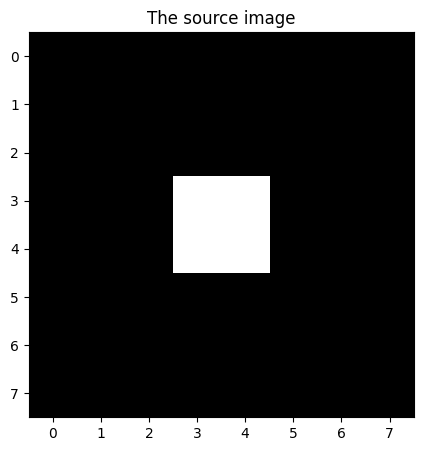

In [50]:
import numpy as np
import matplotlib.pyplot as plt

image = np.zeros((8, 8), dtype=np.uint8)


# Añadir píxeles blancos (valor 255)
image[3:5, 3:5] = 255  # Cuadrado blanco en el centro

# Añadir píxeles grises (valor 128)



# Mostrar la imagen con la cuadrícula
plt.figure(figsize=(5, 5))
plt.imshow(image, cmap='gray', interpolation='nearest')
plt.title("The source image")
plt.show()

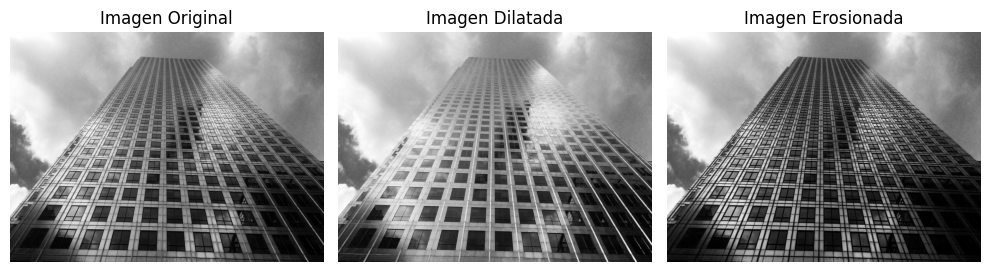

In [54]:
# # Subir la imagen desde el almacenamiento local
# uploaded = files.upload()  # Te pedirá seleccionar una imagen para cargar

# # Leer la imagen cargada
# for filename in uploaded.keys():
#     image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)  # Leer en escala de grises

# Mostrar la imagen original
plt.figure(figsize=(10, 5))
plt.subplot(1, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Imagen Original")
plt.axis('off')

# Crear un elemento estructurante en forma de cruz
# kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
kernel = np.ones((5, 5), np.uint8)

# Aplicar dilatación
dilated = cv2.dilate(image, kernel, iterations=1)

# Mostrar la imagen dilatada
plt.subplot(1, 3, 2)
plt.imshow(dilated, cmap='gray')
plt.title("Imagen Dilatada")
plt.axis('off')

# Aplicar erosión
eroded = cv2.erode(image, kernel, iterations=1)

# Mostrar la imagen erosionada
plt.subplot(1, 3, 3)
plt.imshow(eroded, cmap='gray')
plt.title("Imagen Erosionada")
plt.axis('off')

# Mostrar todas las imágenes juntas
plt.tight_layout()
plt.show()

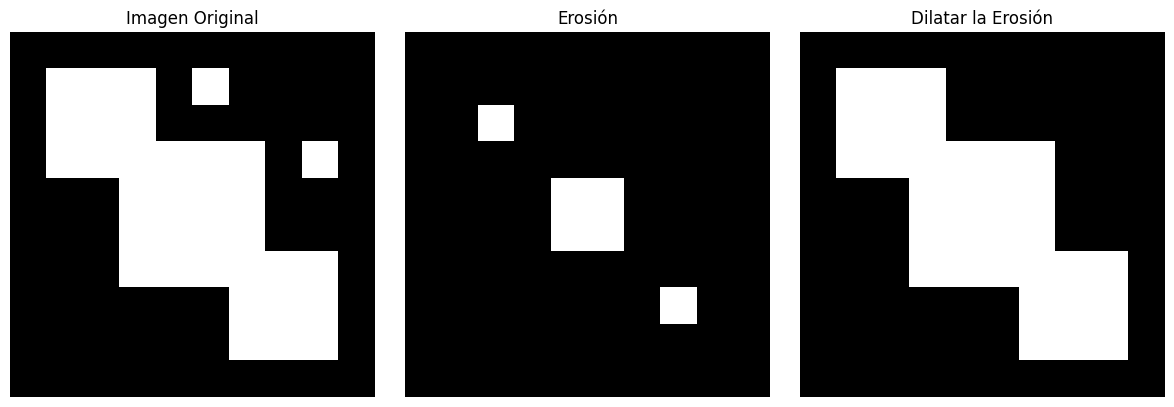

In [61]:
# Crear una imagen binaria inicial
image = np.zeros((10, 10), dtype=np.uint8)
image[1:4, 1:4] = 255  # Primer bloque blanco
image[6:9, 6:9] = 255  # Segundo bloque blanco
image[3:7, 3:7] = 255  # Zona central
image[3, 8] = 255  # Ruido
image[1, 5] = 255  # Ruido

# Crear el elemento estructurante
kernel = np.ones((3, 3), np.uint8)


# Erosión de la imagen
eroded = cv2.erode(image, kernel, iterations=1)

# Dilatación de la imagen erosionada
dilated = cv2.dilate(eroded, kernel, iterations=1)

# Visualización de los pasos
fig, axs = plt.subplots(1, 3, figsize=(12, 4))
axs[0].imshow(image, cmap='gray', interpolation='nearest')
axs[0].set_title("Imagen Original")
axs[0].axis('off')

axs[1].imshow(eroded, cmap='gray', interpolation='nearest')
axs[1].set_title("Erosión")
axs[1].axis('off')

axs[2].imshow(dilated, cmap='gray', interpolation='nearest')
axs[2].set_title("Dilatar la Erosión")
axs[2].axis('off')

plt.tight_layout()
plt.show()

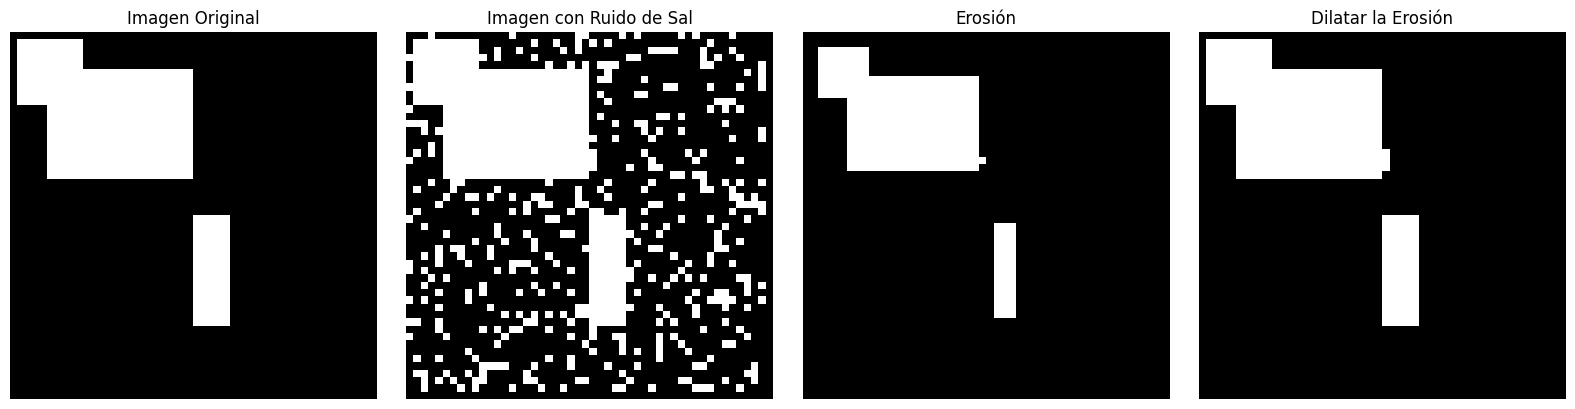

In [66]:
def add_salt_noise(image, salt_prob):
    noisy_image = image.copy()
    num_salt = int(salt_prob * image.size)

    # Generar coordenadas aleatorias para el ruido de sal
    coords = [np.random.randint(0, i - 1, num_salt) for i in image.shape]
    noisy_image[coords[0], coords[1]] = 255  # Asignar blanco (ruido de sal)

    return noisy_image

# Crear una imagen binaria inicial
image = np.zeros((50, 50), dtype=np.uint8)
image[1:10, 1:10] = 255  # Primer bloque blanco
image[25:40, 25:30] = 255  # Segundo bloque blanco
image[5:20, 5:25] = 255  # Zona central

# Agregar ruido de sal a la imagen
salt_prob = 0.2  # Probabilidad del ruido de sal
noisy_image = add_salt_noise(image, salt_prob)

# Crear el elemento estructurante
kernel = np.ones((3, 3), np.uint8)

# Erosión de la imagen
eroded = cv2.erode(noisy_image, kernel, iterations=1)

# Dilatación de la imagen erosionada
dilated = cv2.dilate(eroded, kernel, iterations=1)

# Visualización de los pasos
fig, axs = plt.subplots(1, 4, figsize=(16, 4))
axs[0].imshow(image, cmap='gray', interpolation='nearest')
axs[0].set_title("Imagen Original")
axs[0].axis('off')

axs[1].imshow(noisy_image, cmap='gray', interpolation='nearest')
axs[1].set_title("Imagen con Ruido de Sal")
axs[1].axis('off')

axs[2].imshow(eroded, cmap='gray', interpolation='nearest')
axs[2].set_title("Erosión")
axs[2].axis('off')

axs[3].imshow(dilated, cmap='gray', interpolation='nearest')
axs[3].set_title("Dilatar la Erosión")
axs[3].axis('off')

plt.tight_layout()
plt.show()

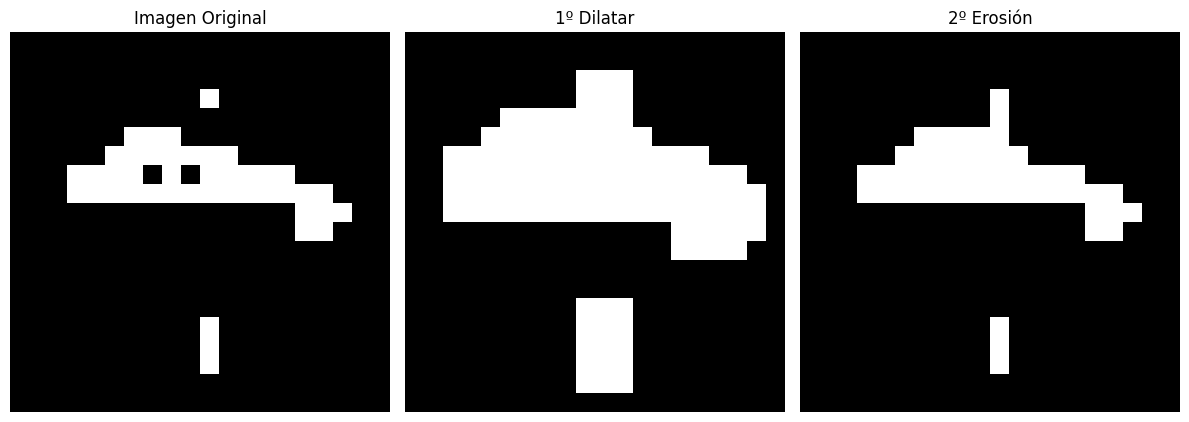

In [87]:
# Crear una matriz de ceros (10x10)
image = np.zeros((20, 20), dtype=np.uint8)

# Definir los píxeles blancos (valor 1)
# Parte superior
image[5, 6:9] = 1
image[6, 5:12] = 1
image[7, 4:15] = 1
image[8, 5:17] = 1
image[9, 15:18] = 1
image[10, 15:17] = 1
image[7, 3:6] = 1
image[8, 3:6] = 1
image[3, 10] = 1
image[15, 10] = 1
image[16, 10] = 1
image[17, 10] = 1

image[7, 7] = 0
image[7, 9] = 0

# Crear el elemento estructurante
kernel = np.ones((3, 3), np.uint8)

# Dilatación de la imagen erosionada
dilated = cv2.dilate(image, kernel, iterations=1)

# Erosión de la imagen
eroded = cv2.erode(dilated, kernel, iterations=1)

# Visualización de los pasos
fig, axs = plt.subplots(1, 3, figsize=(12, 8))
axs[0].imshow(image, cmap='gray', interpolation='nearest')
axs[0].set_title("Imagen Original")
axs[0].axis('off')

axs[1].imshow(dilated, cmap='gray', interpolation='nearest')
axs[1].set_title("1º Dilatar")
axs[1].axis('off')

axs[2].imshow(eroded, cmap='gray', interpolation='nearest')
axs[2].set_title("2º Erosión")
axs[2].axis('off')

plt.tight_layout()
plt.show()

Saving huella.png to huella.png


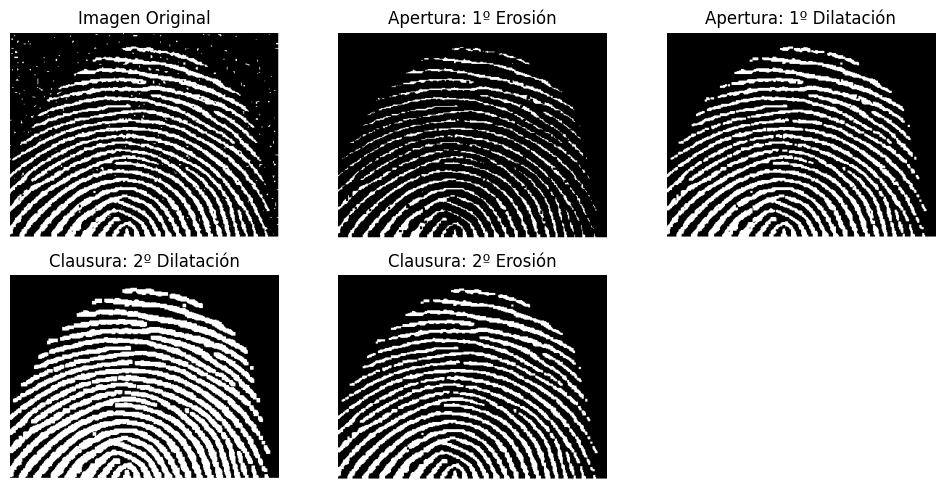

In [2]:
# Subir la imagen desde el almacenamiento local
uploaded = files.upload()  # Te pedirá seleccionar una imagen para cargar

# Leer la imagen cargada
for filename in uploaded.keys():
    image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)  # Leer en escala de grises

# pasar a imagen binaria
_, image = cv2.threshold(image, 127, 255, cv2.THRESH_BINARY)

# Mostrar la imagen original
plt.figure(figsize=(10, 5))
plt.subplot(2, 3, 1)
plt.imshow(image, cmap='gray')
plt.title("Imagen Original")
plt.axis('off')

# Crear un elemento estructurante en forma de cruz
# kernel = cv2.getStructuringElement(cv2.MORPH_CROSS, (5, 5))
kernel = np.ones((3, 3), np.uint8)

# Aplicar 1º erosión
eroded = cv2.erode(image, kernel, iterations=1)
# Aplicar 1º dilatación
dilated = cv2.dilate(eroded, kernel, iterations=1)
# Aplicar 2º dilatación
dilated_2 = cv2.dilate(dilated, kernel, iterations=1)
# Aplicar 2º erosión
eroded_2 = cv2.erode(dilated_2, kernel, iterations=1)

# Mostrar la imagen erosionada
plt.subplot(2, 3, 2)
plt.imshow(eroded, cmap='gray')
plt.title("Apertura: 1º Erosión")
plt.axis('off')

# Mostrar la imagen dilatada
plt.subplot(2, 3, 3)
plt.imshow(dilated, cmap='gray')
plt.title("Apertura: 1º Dilatación")
plt.axis('off')

# Mostrar la imagen dilatada
plt.subplot(2, 3, 4)
plt.imshow(dilated_2, cmap='gray')
plt.title("Clausura: 2º Dilatación")
plt.axis('off')

# Mostrar la imagen erosionada
plt.subplot(2, 3, 5)
plt.imshow(eroded_2, cmap='gray')
plt.title("Clausura: 2º Erosión")
plt.axis('off')

# Mostrar todas las imágenes juntas
plt.tight_layout()
plt.show()

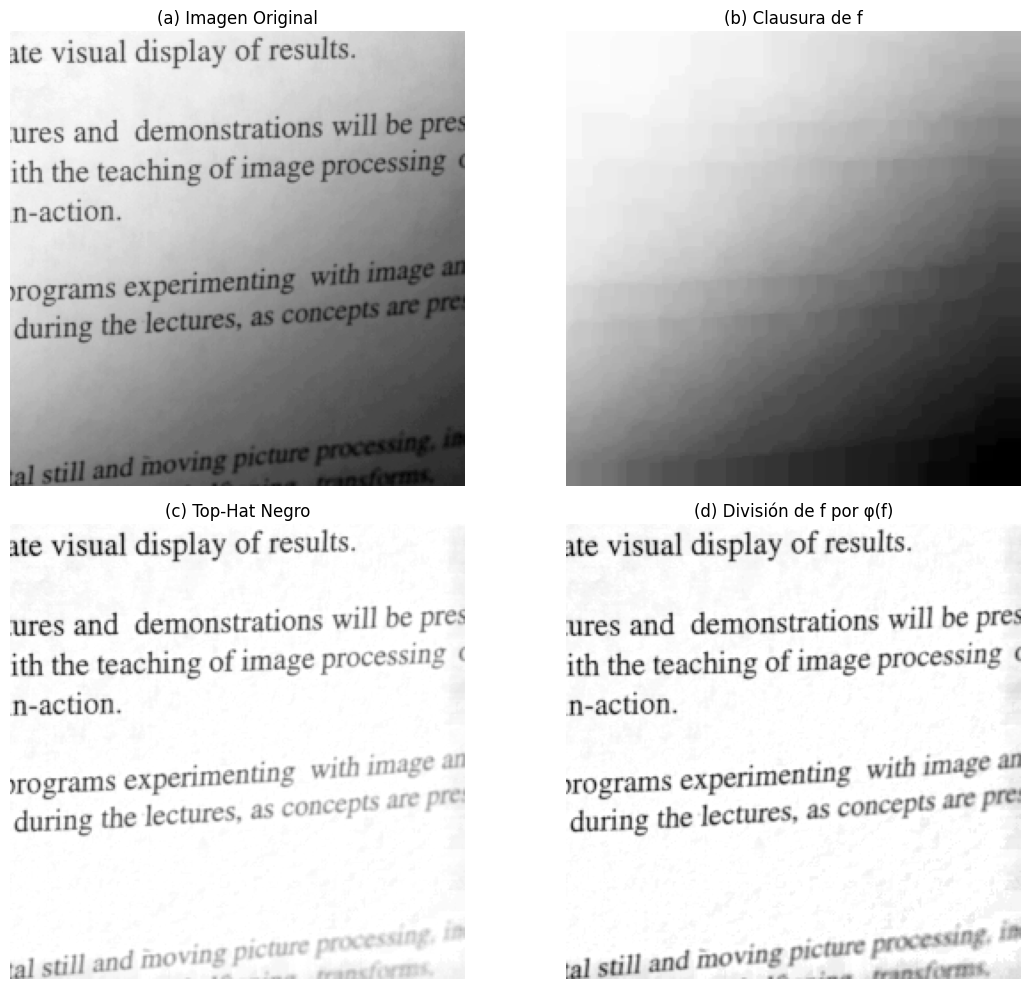

In [144]:
# # Subir la imagen desde local
# uploaded = files.upload()

# # Leer la imagen en escala de grises
# for filename in uploaded.keys():
#     image = cv2.imread(filename, cv2.IMREAD_GRAYSCALE)

# Crear un elemento estructurante grande
kernel_size = 25  # Tamaño del kernel (ajustable según la imagen)
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (kernel_size, kernel_size))

# (a) Imagen original
original_image = image

# (b) Aplicar la clausura a la imagen
closed_image = cv2.morphologyEx(original_image, cv2.MORPH_CLOSE, kernel)

# (c) Top-Hat negro: resta de la clausura con la imagen original
black_tophat = 255-(closed_image - original_image)

# (d) División de la imagen original por la imagen clausurada
# Para evitar divisiones por cero, sumamos una pequeña constante (epsilon)
epsilon = 1e-5
divided_image = cv2.divide(original_image.astype(np.float32) + epsilon,
                           closed_image.astype(np.float32) + epsilon)
divided_image = cv2.normalize(divided_image, None, 0, 255, cv2.NORM_MINMAX).astype(np.uint8)

# Visualizar los resultados
fig, axs = plt.subplots(2, 2, figsize=(12, 10))

# Imagen original
axs[0, 0].imshow(original_image, cmap='gray')
axs[0, 0].set_title("(a) Imagen Original")
axs[0, 0].axis('off')

# Imagen clausurada
axs[0, 1].imshow(closed_image, cmap='gray')
axs[0, 1].set_title("(b) Clausura de f")
axs[0, 1].axis('off')

# Black Top-Hat
axs[1, 0].imshow(black_tophat, cmap='gray')
axs[1, 0].set_title("(c) Top-Hat Negro")
axs[1, 0].axis('off')

# División de f por la clausura
axs[1, 1].imshow(divided_image, cmap='gray')
axs[1, 1].set_title("(d) División de f por φ(f)")
axs[1, 1].axis('off')

plt.tight_layout()
plt.show()

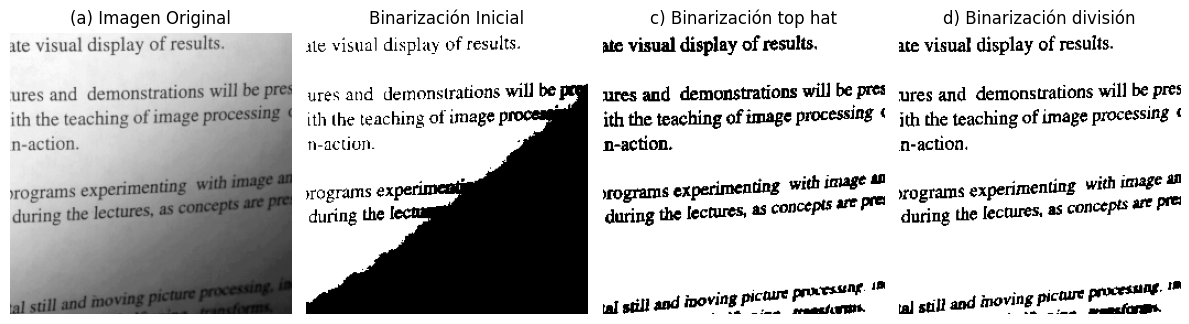

In [148]:
# Visualizar los resultados
fig, axs = plt.subplots(1, 4, figsize=(12, 10))

# Imagen original
axs[0].imshow(original_image, cmap='gray')
axs[0].set_title("(a) Imagen Original")
axs[0].axis('off')

# binarización de imagen original
_, binary_original = cv2.threshold(original_image, 180, 255, cv2.THRESH_BINARY)

axs[1].imshow(binary_original, cmap='gray')
axs[1].set_title("Binarización Inicial")
axs[1].axis('off')

# Binarización de top-hat
_, binary_div = cv2.threshold(divided_image, 200, 255, cv2.THRESH_BINARY)

axs[3].imshow(binary_div, cmap='gray')
axs[3].set_title("d) Binarización división")
axs[3].axis('off')

# Binarización de top-hat
_, binary_tophat = cv2.threshold(black_tophat, 240, 255, cv2.THRESH_BINARY)

axs[2].imshow(binary_tophat, cmap='gray')
axs[2].set_title("c) Binarización top hat")
axs[2].axis('off')


plt.tight_layout()
plt.show()

Saving rice.png to rice (3).png


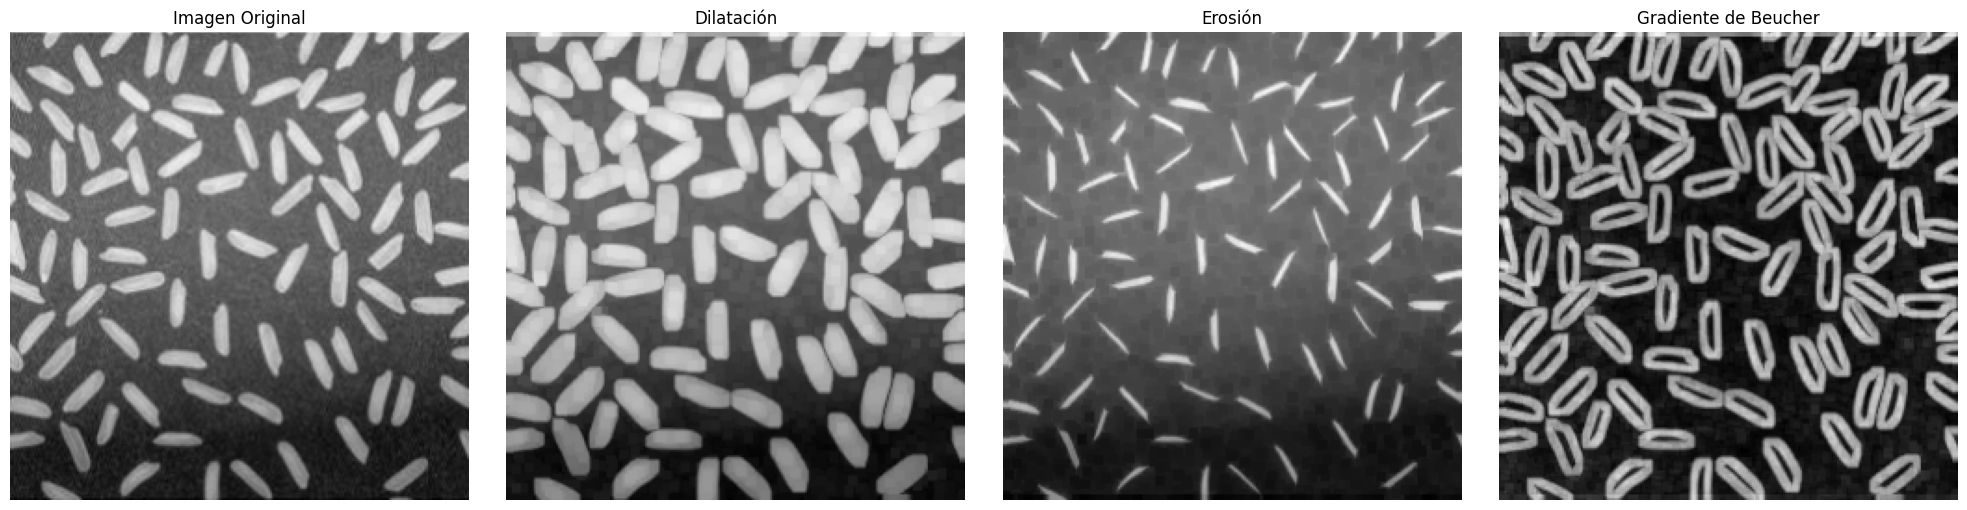

In [11]:
uploaded = files.upload()

# Obtener el nombre del archivo
image_path = list(uploaded.keys())[0]

# Leer la imagen en escala de grises
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Verificar si la imagen se cargó correctamente
if image is None:
    raise ValueError("No se pudo cargar la imagen. Asegúrate de que el archivo es válido.")

# Aplicar dilatación
kernel = np.ones((10, 10), np.uint8)  # Kernel de 5x5
image_dilated = cv2.dilate(image, kernel, iterations=1)

# Aplicar erosión
image_eroded = cv2.erode(image, kernel, iterations=1)

# Calcular el gradiente de Beucher (dilatación - erosión)
gradient_beucher = image_dilated - image_eroded
# Gradiente interno
gradient_interno = image - image_eroded
# Gradiente externo
gradient_externo = image_dilated - image

# Mostrar las imágenes en un plot de 4 columnas y 1 fila
plt.figure(figsize=(20, 5))

# Imagen original
plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Imagen dilatada
plt.subplot(1, 4, 2)
plt.title("Dilatación")
plt.imshow(image_dilated, cmap='gray')
plt.axis('off')

# Imagen erosionada
plt.subplot(1, 4, 3)
plt.title("Erosión")
plt.imshow(image_eroded, cmap='gray')
plt.axis('off')

# Gradiente de Beucher
plt.subplot(1, 4, 4)
plt.title("Gradiente de Beucher")
plt.imshow(gradient_beucher, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

Saving rice.png to rice (1).png


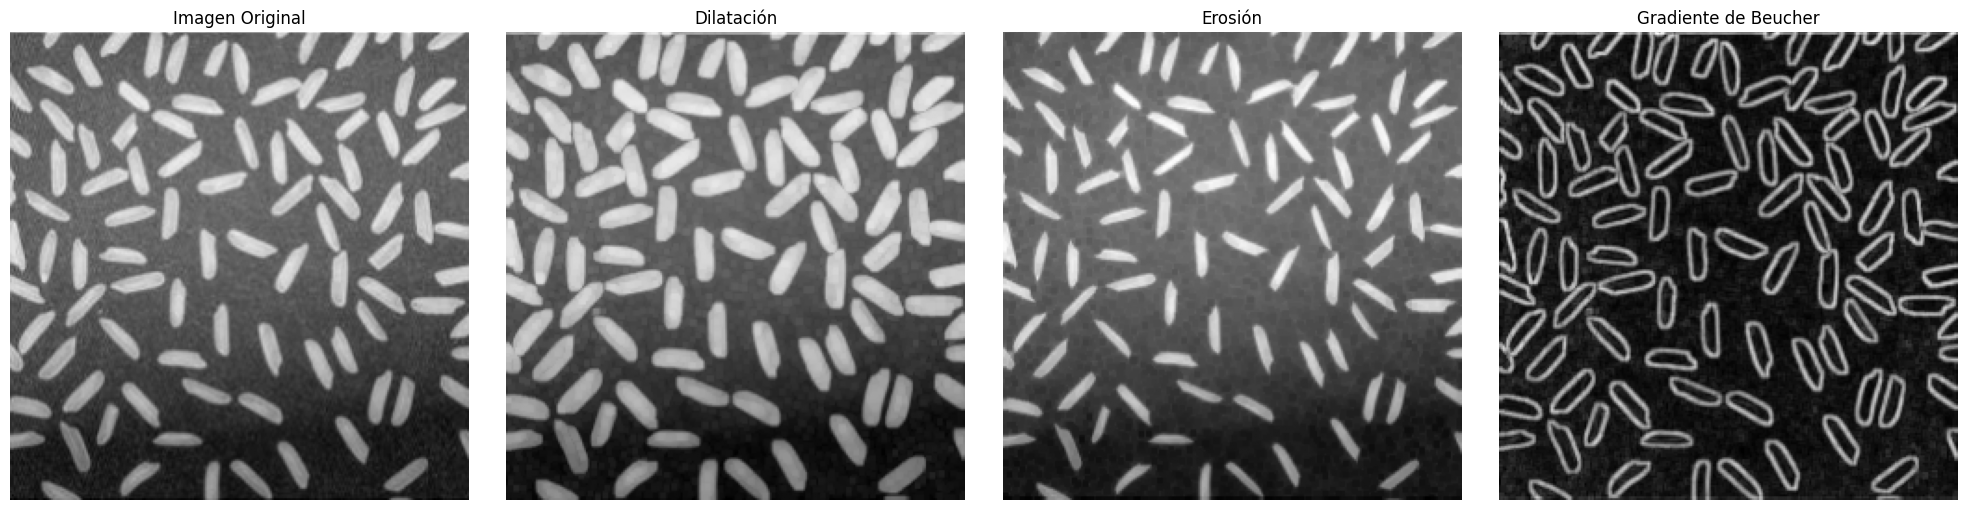

In [4]:
uploaded = files.upload()

# Obtener el nombre del archivo
image_path = list(uploaded.keys())[0]

# Leer la imagen en escala de grises
image = cv2.imread(image_path, cv2.IMREAD_GRAYSCALE)

# Verificar si la imagen se cargó correctamente
if image is None:
    raise ValueError("No se pudo cargar la imagen. Asegúrate de que el archivo es válido.")

# Aplicar dilatación
kernel = np.ones((3, 3), np.uint8)  # Kernel de 5x5
image_dilated = cv2.dilate(image, kernel, iterations=1)

# Aplicar erosión
image_eroded = cv2.erode(image, kernel, iterations=1)

# Calcular el gradiente de Beucher (dilatación - erosión)
gradient_beucher = image_dilated - image_eroded
# Gradiente interno
gradient_interno = image - image_eroded
# Gradiente externo
gradient_externo = image_dilated - image

# Mostrar las imágenes en un plot de 4 columnas y 1 fila
plt.figure(figsize=(20, 5))

# Imagen original
plt.subplot(1, 4, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Imagen dilatada
plt.subplot(1, 4, 2)
plt.title("Dilatación")
plt.imshow(image_dilated, cmap='gray')
plt.axis('off')

# Imagen erosionada
plt.subplot(1, 4, 3)
plt.title("Erosión")
plt.imshow(image_eroded, cmap='gray')
plt.axis('off')

# Gradiente de Beucher
plt.subplot(1, 4, 4)
plt.title("Gradiente de Beucher")
plt.imshow(gradient_beucher, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

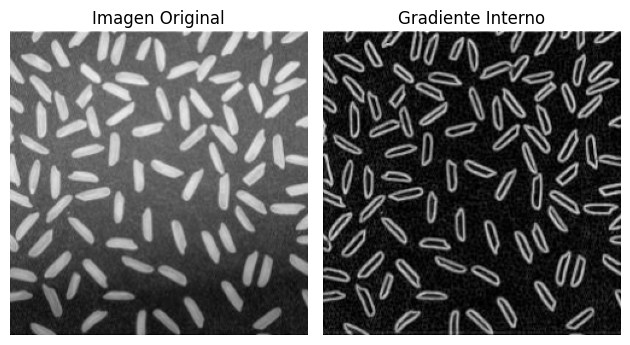

In [12]:
# Imagen original
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Gradiente de Interno
plt.subplot(1, 2, 2)
plt.title("Gradiente Interno")
plt.imshow(gradient_interno, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()

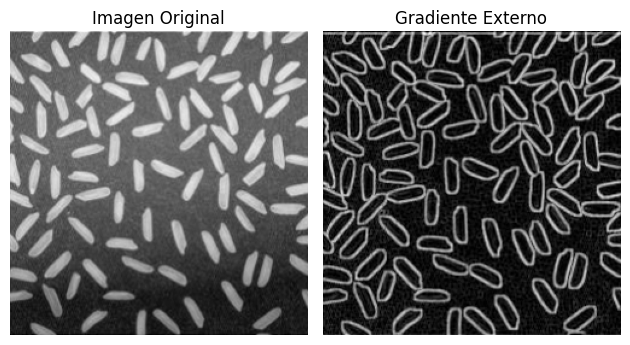

In [13]:
# Imagen original
plt.subplot(1, 2, 1)
plt.title("Imagen Original")
plt.imshow(image, cmap='gray')
plt.axis('off')

# Gradiente de Interno
plt.subplot(1, 2, 2)
plt.title("Gradiente Externo")
plt.imshow(gradient_externo, cmap='gray')
plt.axis('off')

plt.tight_layout()
plt.show()